# Phase 3c — League-relative features (2015/16)

Phases 2 and 3b answer *is this team's fingerprint real?* one team at a time. Neither can
say where a fingerprint sits, because a single team is not a scale. 2015/16 is the first
full-league season in the data, 20 clubs and all 380 fixtures, so it can supply one.

This notebook builds the **era-normalization layer**: a team-season expressed as its position
among its own contemporaries rather than in raw units. That is what makes 2003 and 2015
commensurable at all. A pass-completion percentage from two eras is not the same measurement;
"80th percentile of its own league" is.

Four things get settled here.

1. **Which features the field is built on.** Not Arsenal's frozen registry. The tier is
   re-measured across all 20 clubs.
2. **What gets normalized.** Plain season means, with the reason demonstrated rather than assumed.
3. **The field itself.** Season means re-expressed as z-scores and percentiles within the league.
4. **Whether it measures style or just quality.** The validation gate. If style distance
   recovers the league table, the representation is measuring how good a club is, not how it plays.

The engine is `src/diagnostics/style.py` (Phases 2 and 3b, unchanged) and
`src/representation/style_space.py` (new here, 96 tests).

## Setup

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "src" / "config.py").is_file()
)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FEATURES_DIR, PROCESSED_DIR
from src.features.batch import resolve_opponent_strength
from src.diagnostics.style import (
    diagnose, match_context_design, opponent_style_design, team_season,
)
from src.representation.style_space import league_anchors, style_space

style = pd.read_csv(FEATURES_DIR / "match_team_style_2016.csv")

# Final positions, computed from the season's own results (coverage is full).
matches = pd.read_csv(PROCESSED_DIR / "matches_2016.csv")
position = pd.Series({t: p for t, (p, _) in
                      resolve_opponent_strength("2015/2016", matches).items()})

anchors = league_anchors(style)
space = style_space(style, anchors.features)

print(f"clubs: {anchors.n_teams}   match rows: {len(style)}")
print(f"identity anchors (>= {anchors.min_teams}/{anchors.n_teams} clubs): {len(anchors.features)}")
print(f"spine (all {anchors.n_teams} clubs): {len(anchors.spine)}")
print(f"\nchampions: {', '.join(position.sort_values().index[:4])}")

clubs: 20   match rows: 760
identity anchors (>= 15/20 clubs): 49
spine (all 20 clubs): 15

champions: Leicester City, Arsenal, Tottenham Hotspur, Manchester City


## 1. The identity-anchor tier, measured league-wide

Phase 3 was planned to scope this work to "the identity-anchor tier from the frozen Phase 2
registry", meaning Arsenal's 54. That decision was made when running the diagnostic for one
more team meant copying a notebook. Since the engine was extracted it costs about three
seconds for all twenty.

The reason to spend those seconds is that "identity anchor" in Phase 2 means *stable for
Arsenal*, which is a claim about Arsenal and not about the metric. Using it to normalize
twenty clubs would bake one team's idiosyncrasy into the shared axis. Here a feature earns
the tier by how many clubs it anchors for.

In [10]:
arsenal_reg = pd.read_csv(FEATURES_DIR / "phase2_arsenal_feature_registry.csv")
leicester_reg = pd.read_csv(FEATURES_DIR / "phase3b_leicester_feature_registry.csv")
one_team = {
    "Arsenal 03/04": set(arsenal_reg.loc[arsenal_reg.tier == "identity", "feature"]),
    "Leicester 15/16": set(leicester_reg.loc[leicester_reg.tier == "identity", "feature"]),
}
tier = set(anchors.features)

print("how many of the 20 clubs each feature anchors for:")
print(anchors.counts.value_counts().sort_index(ascending=False)
      .rename_axis("clubs").rename("features").to_string())

print(f"\ntier at >= {anchors.min_teams}/20: {len(tier)} features")
for label, one in one_team.items():
    print(f"  vs {label:16s} ({len(one)} identity): "
          f"{len(tier & one):2d} shared | {len(tier - one):2d} the league adds "
          f"| {len(one - tier):2d} team quirks dropped")
print(f"  the two frozen registries agree with each other on only "
      f"{len(one_team['Arsenal 03/04'] & one_team['Leicester 15/16'])} of ~53")

print(f"\nspine — stable for all 20 clubs ({len(anchors.spine)}):")
for f in anchors.spine:
    print(f"  {f}")

how many of the 20 clubs each feature anchors for:
clubs
20    15
19    15
18     7
17     5
16     4
15     3
14     3
13     1
12     3
11     1
10     1
9      2
8      1
7      1
6      2
5      1
4      3
3      4
2      8
1      5
0     50

tier at >= 15/20: 49 features
  vs Arsenal 03/04    (54 identity): 47 shared |  2 the league adds |  7 team quirks dropped
  vs Leicester 15/16  (52 identity): 43 shared |  6 the league adds |  9 team quirks dropped
  the two frozen registries agree with each other on only 42 of ~53

spine — stable for all 20 clubs (15):
  pi_angle_entropy
  pi_avg_endpoint_depth_std
  pi_avg_passes_to_final_third
  pi_centralization
  pi_connectivity
  pi_early_depth_x_std
  pi_early_width_y_std
  pi_first_forward_pct
  pi_first_into_midfield_or_better_pct
  pi_lateral_circulation_pct
  pi_network_players
  pi_top_player_involvement_pct
  rhythm_mean_avg_progressive_x_gain
  rhythm_mean_burst_share
  rp6_median_events_per_sec


**Reading.** The two frozen registries overlap on 42 features out of roughly 53 each, so
neither is a league-wide axis on its own. Fifteen features are identity anchors for every
club in the league. Phase 3b called `pi_angle_entropy` and the rhythm burst share "universal
identity axes" on the strength of two champions; at 20 of 20 that stops being an anecdote
and becomes a count.

The tier used from here on is the 49 features that anchor for at least 15 clubs. The spine
is reported alongside it because a feature kept at 15 of 20 is a weaker axis than one kept
at 20 of 20, and the margin should be visible rather than implied.

## 2. Why plain season means are enough

Phases 2 and 3b established that venue and opponent strength move these features a lot, which
raises an obvious worry about aggregating a season to a mean. A context-adjusted mean is
available, but it would add a modelling layer whose errors propagate into every downstream
distance. Before reaching for it, the question is whether a full league already cancels the
two confounds. It largely does, and the amount is exactly computable rather than a matter of
opinion.

In [4]:
# Venue: every club plays 19 home and 19 away, so the season mean already IS the
# venue-balanced mean. Not approximately — identically.
home = style[style.venue == "home"].groupby("team")[anchors.features].mean()
away = style[style.venue == "away"].groupby("team")[anchors.features].mean()
gap = (space.profiles - (home + away) / 2).abs()
complete = [f for f in anchors.features if style[f].notna().all()]

print("venue balance")
print(f"  max |season mean - venue-balanced mean| over {len(complete)} complete anchors: "
      f"{gap[complete].to_numpy().max():.2e}")
incomplete = sorted(set(anchors.features) - set(complete))
print(f"  the only anchor with missing matches is {incomplete}, "
      f"max gap {gap[incomplete].to_numpy().max():.4f}")

# Opponent: a club cannot play itself, and that is the entire schedule imbalance.
# Positions sum to 210, so a club finishing p faces a pool averaging (210 - p)/19.
faced = style.groupby("team")["opp_final_position"].mean()
expected = (210 - position) / 19
print(f"\nschedule strength")
print(f"  max |observed - (210 - p)/19|: {(faced - expected).abs().max():.2e}")
print(f"  champion faces a pool averaging position {faced[position.idxmin()]:.2f}, "
      f"bottom club {faced[position.idxmax()]:.2f}")
print(f"  total spread: {faced.max() - faced.min():.2f} of 20 positions")

venue balance
  max |season mean - venue-balanced mean| over 48 complete anchors: 2.27e-13
  the only anchor with missing matches is ['rp6_pressured_pass_completion_pct'], max gap 0.0191

schedule strength
  max |observed - (210 - p)/19|: 0.00e+00
  champion faces a pool averaging position 11.00, bottom club 10.00
  total spread: 1.00 of 20 positions


**Reading.** Venue cancels exactly. The season mean and the mean of the home and away means
agree to floating-point error on all 48 complete anchors, because 19 and 19 are the same
weight. The one anchor with a missing match is the only exception and it moves by 0.02.

The schedule confound has a closed form. A club cannot play itself, so the champion's
opponent pool averages position 11.0 and the bottom club's averages 10.0. One position on a
twenty-position scale, and it runs in the direction that flatters nobody in particular.
Plain season means it is, with the size of what was ignored stated rather than waved away.

## 3. The era-normalized field

Each club becomes one number per anchor, then two positions against the field. The z-score
keeps magnitude and is what distances are measured in. The percentile is the same position
stated the way a reader reads it.

Both are carried because neither is sufficient alone. With 20 clubs a percentile moves in
5-point steps and cannot separate a narrow leader from a runaway one, which is precisely the
thing that makes Leicester interesting.

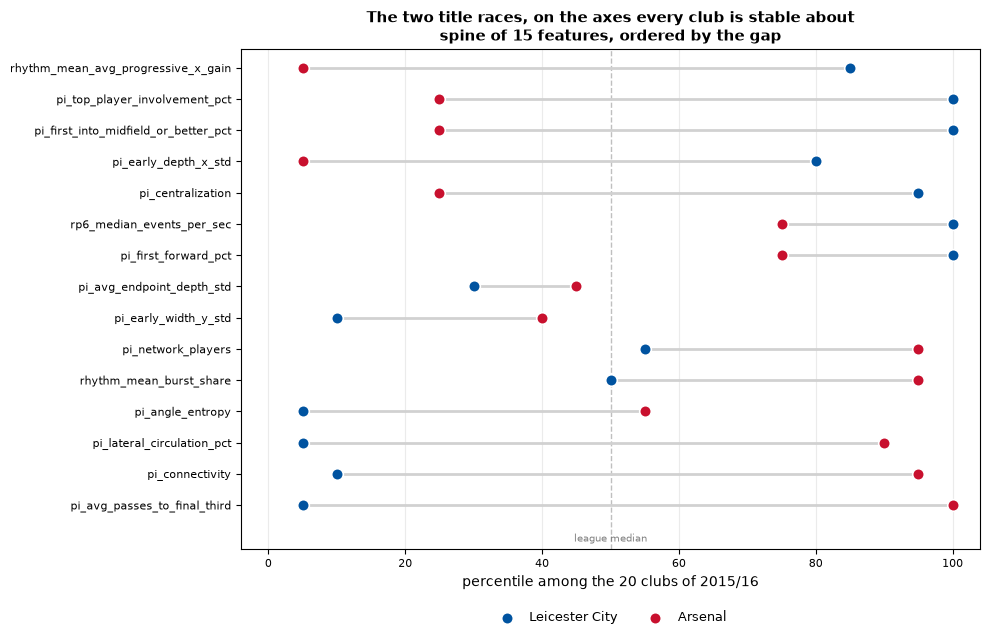

widest separations on the spine:
team                                Leicester City  Arsenal
pi_avg_passes_to_final_third                   5.0    100.0
pi_connectivity                               10.0     95.0
pi_lateral_circulation_pct                     5.0     90.0
rhythm_mean_avg_progressive_x_gain            85.0      5.0


In [5]:
LEICESTER, ARSENAL = "Leicester City", "Arsenal"
CLUB_COLOR = {LEICESTER: "#0053a0", ARSENAL: "#c8102e"}   # club colours, as in 2b/3b

profile = space.percentiles.loc[[LEICESTER, ARSENAL], anchors.spine].T
profile["gap"] = profile[LEICESTER] - profile[ARSENAL]
profile = profile.sort_values("gap")

fig, ax = plt.subplots(figsize=(10, 6.5))
y = np.arange(len(profile))
ax.axvline(50, color="0.75", lw=1, ls="--", zorder=1)
ax.hlines(y, profile[LEICESTER], profile[ARSENAL], color="0.82", lw=2, zorder=2)
for club in (LEICESTER, ARSENAL):
    ax.scatter(profile[club], y, s=70, color=CLUB_COLOR[club], zorder=3,
               edgecolor="white", linewidth=1.2, label=club)

ax.set_yticks(y); ax.set_yticklabels(profile.index, fontsize=8)
ax.set_ylim(-1.4, len(profile) - 0.4)
ax.set_xlim(-4, 104); ax.set_xlabel("percentile among the 20 clubs of 2015/16")
ax.text(50, -1.25, "league median", fontsize=7.5, color="0.5", ha="center", va="bottom")
ax.set_title("The two title races, on the axes every club is stable about\n"
             f"spine of {len(anchors.spine)} features, ordered by the gap",
             fontweight="bold", fontsize=11)
# Legend below the axes: the lower-right corner holds a data point.
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2,
          frameon=False, fontsize=9)
ax.grid(axis="x", alpha=0.25); ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

widest = profile["gap"].abs().sort_values(ascending=False).head(4).index
print("widest separations on the spine:")
print(profile.loc[widest, [LEICESTER, ARSENAL]].round(0).to_string())

**Reading.** Leicester and Arsenal sit at opposite ends of the same axes, and the gaps are
large. Arsenal need more passes to reach the final third than any club in the league (100th
percentile) against Leicester's 5th; Arsenal are 95th on network connectivity and 90th on
lateral circulation against Leicester's 10th and 5th. The one that runs the other way is
progressive x gain per possession, where Leicester are 85th and Arsenal 5th. Patient
circulation against ground gained.

Not every anchor separates them. Passing-angle entropy, the single lowest-CV feature for both
clubs in Phases 2 and 3b, puts Leicester at the 5th percentile but Arsenal only at the 55th.
A feature can be the most stable thing a club does and still be unremarkable league-wide,
which is the distinction between a within-team anchor and a between-team axis, and the reason
this phase exists.

The two clubs finished first and second, ten points apart, with close to mirrored style
profiles. Whatever these axes measure, it is not how good a team is. Section 4 tests that.

## 4. Similarity, and the gate

The gate for this phase: if distance in the field recovers the league table, the
representation is measuring quality and the "identity anchor" label is wrong. The check is
a rank correlation, per club, between style distance and league-position gap.

Distance is Euclidean in z-space. Percentiles are ranks and throw away the size of the gap
between clubs, which is the part that matters for a distance.

In [6]:
rows = []
for team in space.teams:
    style_gap = space.distances[team].drop(index=team)
    table_gap = (position.drop(team) - position[team]).abs().reindex(style_gap.index)
    rows.append({"team": team, "position": position[team],
                 "rho": stats.spearmanr(style_gap, table_gap).statistic})
gate = pd.DataFrame(rows).set_index("team").sort_values("rho")

print("spearman(style distance, league-position gap), per club")
print(f"  mean {gate.rho.mean():+.3f}   range {gate.rho.min():+.3f} to {gate.rho.max():+.3f}")
print(f"\nmost negative (plays least like the clubs it finished near):")
print(gate.head(3).round(3).to_string())

print("\nnearest neighbours in style")
for club in (LEICESTER, ARSENAL):
    near = space.neighbours(club, 3)
    tail = ", ".join(f"{t} ({position[t]}{'th' if position[t] > 3 else ''}, d={d:.1f})"
                     for t, d in near.items())
    print(f"  {club} ({position[club]}): {tail}")

spearman(style distance, league-position gap), per club
  mean +0.159   range -0.556 to +0.508

most negative (plays least like the clubs it finished near):
                 position    rho
team                            
Leicester City          1 -0.556
West Ham United         7 -0.403
AFC Bournemouth        16 -0.170

nearest neighbours in style
  Leicester City (1): Watford (13th, d=7.2), Sunderland (17th, d=7.5), Crystal Palace (15th, d=8.4)
  Arsenal (2): Chelsea (10th, d=4.5), Liverpool (8th, d=6.9), Manchester City (4th, d=7.8)


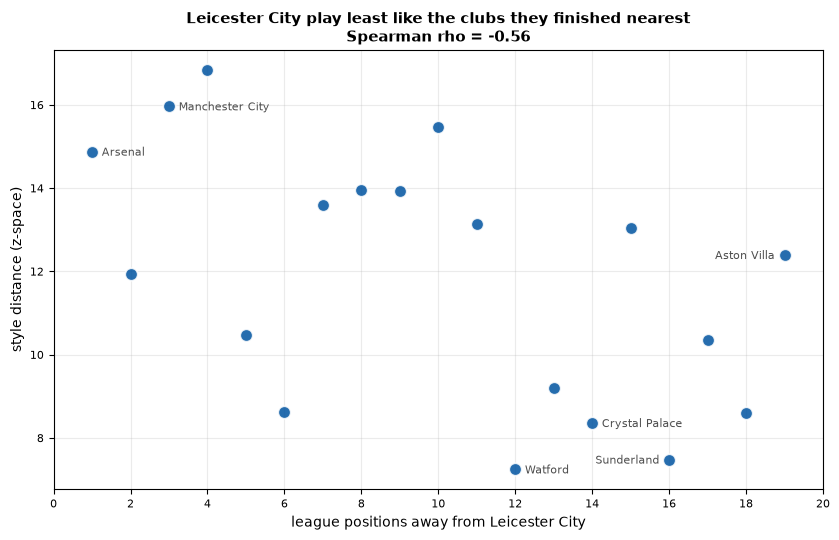

In [7]:
club = LEICESTER
style_gap = space.distances[club].drop(index=club)
table_gap = (position.drop(club) - position[club]).abs().reindex(style_gap.index)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(table_gap, style_gap, s=80, color=CLUB_COLOR[club], alpha=0.85,
           edgecolor="white", linewidth=1.2, zorder=3)

# Label the nearest three and the clubs a reader will look for. Anchor the text
# on the side with room so nothing runs off the axes.
label = list(space.neighbours(club, 3).index) + ["Arsenal", "Manchester City", "Aston Villa"]
for team in dict.fromkeys(label):
    x, y = table_gap[team], style_gap[team]
    right = x < table_gap.max() - 3
    ax.annotate(team, (x, y), fontsize=8, color="0.3",
                ha="left" if right else "right",
                xytext=(7 if right else -7, -3), textcoords="offset points")

# No trend line: the claim in the title is a rank correlation, and a
# least-squares line would be a different statistic drawn over it.
ax.set_xlabel(f"league positions away from {club}")
ax.set_ylabel("style distance (z-space)")
ax.set_xticks(range(0, int(table_gap.max()) + 2, 2))
ax.set_title(f"{club} play least like the clubs they finished nearest\n"
             f"Spearman rho = {gate.loc[club, 'rho']:+.2f}",
             fontweight="bold", fontsize=11)
ax.grid(alpha=0.25); ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

**Reading.** Across the twenty clubs the mean rank correlation between style distance and
league-position gap is +0.16. The field does not recover the table, so the anchors are
measuring how a club plays rather than how well.

Leicester are the strongest exception, and in the informative direction. Their correlation is
−0.56, the most negative in the league: the further a club finished from Leicester, the more
Leicester played like them. Their three nearest neighbours in style are Watford, Sunderland
and Crystal Palace, who finished 13th, 17th and 15th. Arsenal's are Chelsea, Liverpool and
Manchester City.

That is the 2015/16 title in one number. Leicester won the league playing like the bottom
half, and a representation that put them next to Arsenal and Manchester City would be wrong.

## 5. The opponent's measured style as a covariate

The third thing a full league unlocks. Phases 1 to 3b proxy the opponent with final league
position, a number from outside the event data. With every club's season available, the
covariate can be what the opponent actually does on the ball. `opponent_style_design` swaps
one for the other at the design seam; the engine is untouched.

The question is whether the measured covariate is better. It is worth checking rather than
assuming, and the answer here is mostly no.

In [8]:
CANDIDATES = ["poss_mean_directness", "pass_completion_pct", "pi_avg_passes_to_final_third"]

rows = []
for club in (LEICESTER, ARSENAL):
    ts = team_season(style, club)
    base = diagnose(ts)
    live = [f for f in anchors.features if f in base.live]
    rows.append({"club": club, "covariate": "final position (proxy)",
                 "mean_r2": np.mean([base.fit(f).r2 for f in live]),
                 "significant": sum(base.fit(f).p["opp"] < 0.05 for f in live)})
    for cov in CANDIDATES:
        d = diagnose(ts, design=opponent_style_design(style, cov))
        rows.append({"club": club, "covariate": f"measured: {cov}",
                     "mean_r2": np.mean([d.fit(f).r2 for f in live]),
                     "significant": sum(d.fit(f).p["opp_style"] < 0.05 for f in live)})

comparison = pd.DataFrame(rows)
print(f"context R^2 over the {len(anchors.features)} anchors, and how many have a "
      "significant opponent coefficient\n")
for club, block in comparison.groupby("club", sort=False):
    print(club)
    print(block.drop(columns="club").to_string(index=False,
          formatters={"mean_r2": "{:.3f}".format}))
    print()

context R^2 over the 49 anchors, and how many have a significant opponent coefficient

Leicester City
                             covariate mean_r2  significant
                final position (proxy)   0.145           13
        measured: poss_mean_directness   0.143           11
         measured: pass_completion_pct   0.136           13
measured: pi_avg_passes_to_final_third   0.113            2

Arsenal
                             covariate mean_r2  significant
                final position (proxy)   0.141           16
        measured: poss_mean_directness   0.155           14
         measured: pass_completion_pct   0.158           14
measured: pi_avg_passes_to_final_third   0.085            1



**Reading.** A negative result, reported as one.

Neither covariate wins. For Leicester the final-position proxy explains marginally more of the
anchor variance than any measured axis (0.145 against 0.143 at best) and flags 13 anchors as
significant against 11. For Arsenal the best measured axis explains more (0.158 against 0.141)
but flags fewer (14 against 16). The margins are within noise in both directions, and swapping
a covariate that is free for one that costs a modelling assumption needs a better reason than
this.

The result that does matter is how much the choice of axis changes the answer.
`pi_avg_passes_to_final_third` as the opponent covariate fits *worse* than the proxy for both
clubs (0.113 and 0.085) and flags almost nothing (2 anchors and 1). "The opponent's measured
style" is not one covariate, it is a choice of axis, and choosing badly is worse than using
the table.

Final position stays the default in `match_context_design`. The measured covariate stays
available at the seam for a phase with a specific reason to prefer a specific axis.

## 6. Hand-off to Phase 3d

Phase 3d asks where Arsenal 2003/04 sits among the 2015/16 clubs. That season is Arsenal-only,
so it can never define a field; it can only be placed in one. `place` does that arithmetic.

Running it here is a plumbing check, not a finding. The output is also the clearest possible
argument for the confound ledger 3d was already scoped to carry.

In [9]:
style_2004 = pd.read_csv(FEATURES_DIR / "match_team_style_2004.csv")
invincibles = style_2004[style_2004.team == "Arsenal"][anchors.features].mean()
placed = space.place(invincibles).sort_values("z")

off_the_scale = placed[placed.z.abs() > 2.5]
print(f"Arsenal 2003/04 placed in the 2015/16 field ({len(anchors.features)} anchors)")
print(f"  beyond +/-2.5 sd of the 2015/16 clubs: {len(off_the_scale)} of {len(placed)}")
print(f"  at the 0th or 100th percentile: {int((placed.percentile.isin([0, 100])).sum())}")
print("\nmost extreme:")
print(pd.concat([placed.head(3), placed.tail(3)]).round(2).to_string())

# --- freeze the artifacts for 3d and Phase 4 ---
tier_out = pd.DataFrame({
    "feature": anchors.counts.index,
    "n_identity_clubs": anchors.counts.values,
})
tier_out["in_tier"] = tier_out.feature.isin(anchors.features)
tier_out["in_spine"] = tier_out.feature.isin(anchors.spine)
tier_out = tier_out.sort_values(["n_identity_clubs", "feature"], ascending=[False, True])
tier_out.to_csv(FEATURES_DIR / "phase3c_league_anchors_2016.csv", index=False)

field_out = (space.profiles.stack().rename("season_mean").to_frame()
             .join(space.z.stack().rename("z"))
             .join(space.percentiles.stack().rename("percentile"))
             .rename_axis(["team", "feature"]).reset_index())
field_out.to_csv(FEATURES_DIR / "phase3c_style_space_2016.csv", index=False)

print(f"\nwrote phase3c_league_anchors_2016.csv ({len(tier_out)} features)")
print(f"wrote phase3c_style_space_2016.csv ({len(field_out)} rows = "
      f"{anchors.n_teams} clubs x {len(anchors.features)} anchors)")

Arsenal 2003/04 placed in the 2015/16 field (49 anchors)
  beyond +/-2.5 sd of the 2015/16 clubs: 5 of 49
  at the 0th or 100th percentile: 9

most extreme:
                           value     z  percentile
rp6_mean_start_x           33.12 -3.49         0.0
pi_network_players         13.00 -2.74         5.0
rp6_mean_end_x             86.74 -2.46         0.0
pi_regular_play_buildups   46.47  3.14       100.0
pi_first_forward_pct       74.08  3.60       100.0
poss_possessions          108.87  5.69       100.0

wrote phase3c_league_anchors_2016.csv (135 features)
wrote phase3c_style_space_2016.csv (980 rows = 20 clubs x 49 anchors)


**Reading, and the warning 3d needs.** Most axes place unremarkably. The median absolute z is
0.71, so on a typical anchor the Invincibles land inside the 2015/16 field where they should.
The problem is concentrated: 9 of 49 axes fall beyond two standard deviations and 5 beyond
2.5, and 9 land at the 0th or 100th percentile with no idea how far past the edge they are.

`poss_possessions` comes out at z = +5.7, which claims the Invincibles had far more
possessions per match than any club in 2015/16. No football side is five standard deviations
from a league. That number is about how possessions were segmented in a 2003/04 dataset
collected retrospectively, not about how Arsenal played. `rp6_mean_start_x` at −3.5 and
`pi_first_forward_pct` at +3.6 deserve the same suspicion.

The arithmetic is correct and the interpretation would be wrong, which is exactly what a
confound ledger exists to catch. Two things follow for Phase 3d. Treat any placed axis beyond
about two standard deviations as a data-provenance question before a football question. And
prefer the axes where the two seasons' distributions genuinely overlap, which on this evidence
is most of them but not the loudest ones.

## Synthesis

- The identity-anchor tier is now a **measured property of a feature**, not an inherited
  property of Arsenal. 49 features anchor for at least 15 of the 20 clubs, 15 for all of them.
  Arsenal's frozen registry would have kept 7 features no other club is stable about and
  missed 2 the league agrees on; Leicester's would have missed 6.
- **Plain season means are the right aggregate**, and the reasons are quantified rather than
  assumed. Venue cancels exactly at 19 and 19 (agreement to 2e-13); the schedule confound has
  a closed form and is one position wide out of twenty.
- The field carries **z-scores and percentiles** together, because a 20-club percentile cannot
  express magnitude and a z-score cannot be read aloud.
- **The gate passes.** Mean rank correlation between style distance and league-position gap is
  +0.16, so the representation separates style from quality. Leicester at −0.56 is the case
  that proves it, playing like the bottom half while winning the league.
- The **measured opponent covariate does not beat the final-position proxy**, and is sharply
  sensitive to which axis is chosen. Reported as a negative result; the seam stays available.
- The **cross-era hand-off works and needs a guard**. `place` is correct arithmetic that will
  produce nonsense football on the handful of axes where the two datasets disagree about what
  they are counting.

Frozen for Phase 3d and Phase 4: `phase3c_league_anchors_2016.csv` and
`phase3c_style_space_2016.csv`.